In [2]:
#检测图片中绿色荧光颗粒的数量和大小分布，拟合出分布曲线
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math
from scipy.stats import expon

In [18]:
# 读取图像（请将'image.png'替换为您的实际图像文件路径）
img = cv2.imread("D:/Research/mf_series/distribution20_200/fluo/241007_dsitribution_series_t01_ch00.tif")


def get_distribution(img):
# 创建一个副本用于绘制标记
    img_result = img.copy()

# 将图像从BGR颜色空间转换为RGB颜色空间
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 定义绿色的颜色范围（根据您图像中的绿色色调调整这些值）
    lower_green = np.array([0, 100, 0])
    upper_green = np.array([255, 255, 255])

# 创建一个二值掩码，绿色区域为白色，其余为黑色
    mask = cv2.inRange(img_rgb, lower_green, upper_green)

# 在二值图像中查找轮廓
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 存储面积平方根的列表
    area_sqrt_list = []

# 遍历每个轮廓
    for cnt in contours:
    # 计算轮廓的面积
        area = cv2.contourArea(cnt)
        if area > 0:
        # 计算轮廓的周长
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0:
                continue
        # 计算圆形度，以判断形状是否近似圆形
            circularity = 4 * np.pi * (area / (perimeter ** 2))
        # 如果圆形度高于阈值（1为完美圆形）
            if circularity > 0.24:
            # 计算面积的平方根
                area_sqrt = np.sqrt(area/np.pi)
            #area_sqrt中每个元素除以7.68，得到微米单位
                area_sqrt = area_sqrt/7.68
            # 将结果添加到列表中
                area_sqrt_list.append(area_sqrt)
    return area_sqrt_list

#获取分布的lambda值
def get_lambda(area_sqrt_list):
    # 计算平均值
    mean = np.mean(area_sqrt_list)
    # 计算标准差
    std = np.std(area_sqrt_list)
    # 计算lambda值
    lambda_val = 1 / mean
    return lambda_val

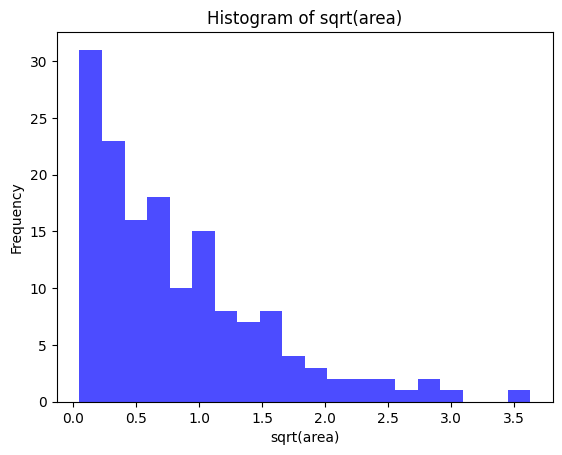

In [21]:
area_sqrt_list = get_distribution(img)

#绘制area_sqrt_list的直方图
plt.hist(area_sqrt_list, bins=20, color='blue', alpha=0.7)
plt.xlabel('sqrt(area)')
plt.ylabel('Frequency')
plt.title('Histogram of sqrt(area)')
plt.show()

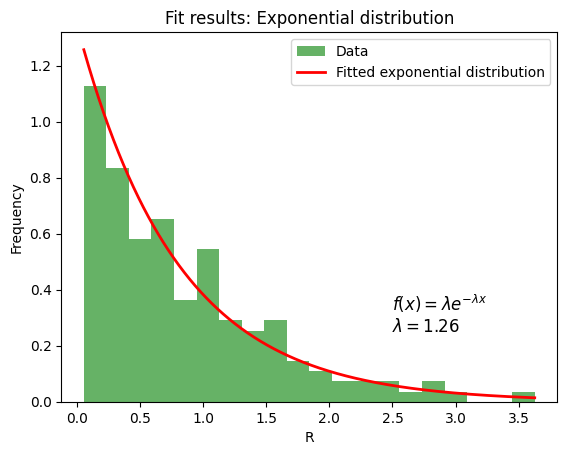

估计的loc（位置参数）：0.05194560942726988
估计的scale（尺度参数）：0.7957657382565748
估计的λ（1/scale）：1.2566512378264456


In [22]:

data = np.array(area_sqrt_list)
# 将数据转换为NumPy数组
data = np.array(data)


# 拟合指数分布，获取位置参数（loc）和尺度参数（scale）
loc, scale = expon.fit(data)

# 生成用于绘制拟合曲线的x值
x = np.linspace(min(data), max(data), 1000)
pdf_fitted = expon.pdf(x, loc=loc, scale=scale)

# 绘制数据的直方图
plt.hist(data, bins=20, density=True, alpha=0.6, color='g', label='Data')

# 绘制拟合的指数分布曲线
plt.plot(x, pdf_fitted, 'r-', lw=2, label='Fitted exponential distribution')

# 添加标题和标签
plt.title('Fit results: Exponential distribution')
plt.xlabel('R')
plt.ylabel('Frequency')

# 显示图例
plt.legend()

#图上写出拟合的指数分布的公式
plt.text(2.5, 0.25, f'$f(x) = \lambda e^{{-\lambda x}}$ \n$\lambda = {1/scale:.2f}$', fontsize=12)

# 展示绘图
plt.show()

# 输出估计的参数
print(f'估计的loc（位置参数）：{loc}')
print(f'估计的scale（尺度参数）：{scale}')
print(f'估计的λ（1/scale）：{1/scale}')


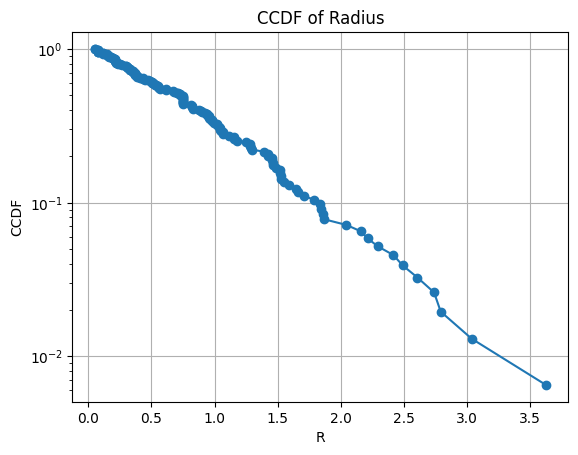

In [26]:

# 根据 area_sqrt_list 绘制 CCDF 的对数图
# 将 area_sqrt_list 转换为 NumPy 数组
data = np.array(area_sqrt_list)

# 对数据进行升序排序
sorted_data =np.sort(data)
scale = 1 / get_lambda(area_sqrt_list)
# 数据点的总数
n = len(data)

# 计算 CCDF（1 - CDF）
ccdf = (n - np.arange(n)) / n

# 为避免取对数时出现零，替换零值为一个很小的数
ccdf[ccdf == 0] = np.finfo(float).eps

# 计算 CCDF 的对数
log_ccdf = np.log(ccdf)
plt.figure()
#添加直线y=-lambda*x的图像

plt.plot(sorted_data, -scale*sorted_data, linestyle='--', color='red', label='y=-λx')

# 绘制面积平方根与 log(1 - CDF) 的关系图

plt.plot(sorted_data, ccdf, marker='o', linestyle='-')
plt.xlabel('R')
plt.ylabel('CCDF')
plt.yscale('log')
plt.title('CCDF of Radius')
plt.grid(True)
plt.show()

拟合结果：a = 1.4728, b = -0.0838
R^2 = 0.9085


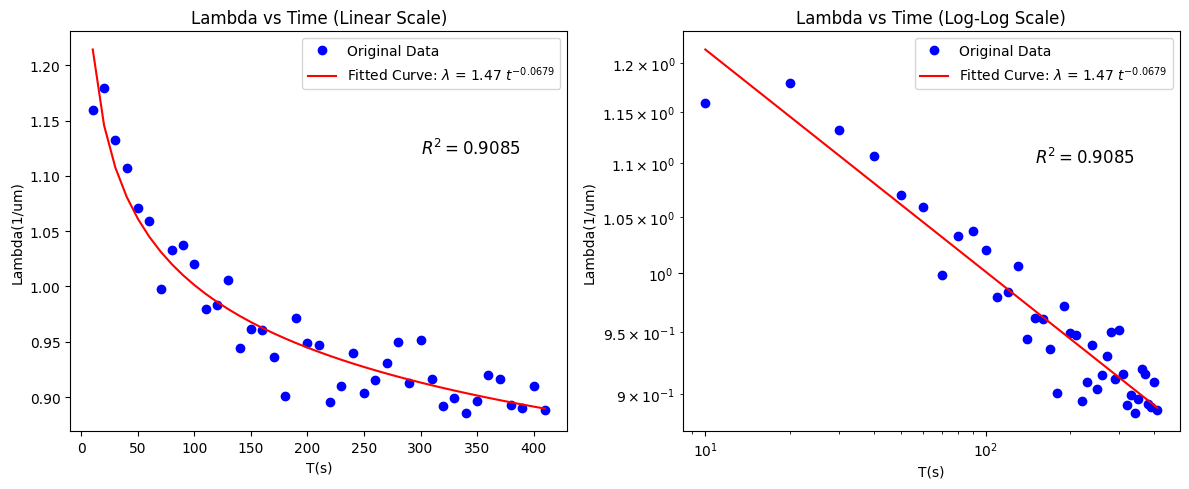

In [43]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 原始代码的部分
path = "D:/Research/mf_series/distribution20_200/fluo"
files = os.listdir(path)
lambdas = []

# 描绘lambda值随时间的变化,取前60张图片
k = 0
for file in files:
    if k > 40:
        break
    k += 1

    img = cv2.imread(path + "/" + file)
    area_sqrt_list = get_distribution(img)
    lambda_val = get_lambda(area_sqrt_list)
    lambdas.append(lambda_val)

times = [10 * (i+1) for i in range(len(lambdas))]

# 对数线性回归拟合lambda与T的幂律分布关系
def power_law(t, a, b):
    return a * np.power(t, b)

# 对数变换后进行线性拟合
log_times = np.log(times)
log_lambdas = np.log(lambdas)

# 使用numpy的polyfit来进行线性拟合
slope, intercept = np.polyfit(log_times, log_lambdas, 1)

# 根据拟合结果得到a和b
a = np.exp(intercept)
b = slope

print(f'拟合结果：a = {a:.4f}, b = {b:.4f}')

# 使用拟合参数绘制拟合曲线
fitted_lambdas = power_law(np.array(times), a, b)

#计算拟合的R^2值
y_pred = power_law(np.array(times), a, b)
ss_res = np.sum((np.log(lambdas) - np.log(y_pred)) ** 2)
ss_tot = np.sum((np.log(lambdas) - np.mean(np.log(lambdas))) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(f'R^2 = {r_squared:.4f}')


# 绘制线性坐标轴下的结果
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(times, lambdas, 'bo', label='Original Data')
plt.plot(times, fitted_lambdas, 'r-', label=f'Fitted Curve: $\lambda$ = {a:.2f} $t^{{-0.0679}}$')
plt.text(300, 1.12, f'$R^2 = {r_squared:.4f}$', fontsize=12)
plt.xlabel('T(s)')
plt.ylabel('Lambda(1/um)')
plt.title('Lambda vs Time (Linear Scale)')
plt.legend()

# 绘制对数坐标轴下的结果（使用原始数值，但尺度为对数）
plt.subplot(1, 2, 2)
plt.plot(times, lambdas, 'bo', label='Original Data')
plt.plot(times, fitted_lambdas, 'r-', label=f'Fitted Curve: $\lambda$ = {a:.2f} $t^{{-0.0679}}$')
#标出拟合的R^2值
plt.text(150, 1.1, f'$R^2 = {r_squared:.4f}$', fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('T(s)')
plt.ylabel('Lambda(1/um)')
plt.title('Lambda vs Time (Log-Log Scale)')
plt.legend()


plt.tight_layout()
